In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Customer_Churn_Cleaned.csv.xlsx to Customer_Churn_Cleaned.csv.xlsx


In [7]:
file_name = next(iter(uploaded))
df = pd.read_excel(file_name)
print("File loaded successfully:", file_name)

File loaded successfully: Customer_Churn_Cleaned.csv.xlsx


In [8]:
#View first 5 rows
df.head()

,Customer_ID,Gender,Age,Tenure_Months,Contract_Type,Payment_Method,Customer_Segment,Monthly_Charges,Total_Charges,Churn,Tenure_Group,Churn_Flag
0,CUST0001,Male,34,20,Month-to-Month,Credit Card,Adult,48.83,944.11,No,13-24 Months,0
1,CUST0002,Female,26,61,Two Year,Credit Card,Young,61.28,3654.12,No,49+ Months,0
2,CUST0003,Male,50,35,One Year,Bank Transfer,Senior,53.72,1744.21,No,25-48 Months,0
3,CUST0004,Male,70,50,One Year,Credit Card,Senior,31.39,1644.26,No,49+ Months,0
4,CUST0005,Male,37,62,Month-to-Month,Credit Card,Adult,31.69,2105.05,No,49+ Months,0


In [9]:
#Check rows and columns
df.shape

(1000, 12)

In [10]:
#Check column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       1000 non-null   object 
 1   Gender            1000 non-null   object 
 2   Age               1000 non-null   int64  
 3   Tenure_Months     1000 non-null   int64  
 4   Contract_Type     1000 non-null   object 
 5   Payment_Method    1000 non-null   object 
 6   Customer_Segment  1000 non-null   object 
 7   Monthly_Charges   1000 non-null   float64
 8   Total_Charges     1000 non-null   float64
 9   Churn             1000 non-null   object 
 10  Tenure_Group      1000 non-null   object 
 11  Churn_Flag        1000 non-null   int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 93.9+ KB


In [11]:
#Check missing values
df.isnull().sum()

,0
Customer_ID,0
Gender,0
Age,0
Tenure_Months,0
Contract_Type,0
Payment_Method,0
Customer_Segment,0
Monthly_Charges,0
Total_Charges,0
Churn,0


In [12]:
#Check duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
#Basic statistics
df.describe()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Churn_Flag
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,44.294000,35.027000,83.639970,2916.682100,0.274000
std,15.420485,20.692183,37.419791,2322.239827,0.446232
min,18.000000,1.000000,20.020000,40.820000,0.000000
25%,31.000000,17.000000,51.525000,1077.632500,0.000000
50%,44.000000,34.000000,83.100000,2316.130000,0.000000
75%,57.000000,52.000000,115.550000,4185.910000,1.000000
max,70.000000,72.000000,149.600000,11144.300000,1.000000


In [14]:
#Overall churn
df['Churn'].value_counts()

,count
Churn,
No,726
Yes,274


In [15]:
#Percentage of customer in each churn category
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,72.6
Yes,27.4


In [16]:
#Churn by contract
contract_churn = pd.crosstab(
    df['Contract_Type'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn)

Churn                  No        Yes
Contract_Type                       
Month-to-Month  65.567766  34.432234
One Year        80.578512  19.421488
Two Year        81.603774  18.396226


In [17]:
#Churn by payment
payment_churn = pd.crosstab(
    df['Payment_Method'],
    df['Churn'],
    normalize='index'
) * 100

print(payment_churn)

Churn                    No        Yes
Payment_Method                        
Bank Transfer     75.462963  24.537037
Credit Card       80.000000  20.000000
Electronic Check  66.463415  33.536585
UPI               69.633508  30.366492
Unknown           80.000000  20.000000


In [18]:
#Churn by customer segemnt
segment_churn = pd.crosstab(
    df['Customer_Segment'],
    df['Churn'],
    normalize='index'
) * 100

print(segment_churn)

Churn                    No        Yes
Customer_Segment                      
Adult             74.450549  25.549451
Senior            69.682152  30.317848
Young             74.889868  25.110132


In [19]:
#Churn by tenure
tenure_churn = pd.crosstab(
    df['Tenure_Group'],
    df['Churn'],
    normalize='index'
) * 100

print(tenure_churn)

Churn                No        Yes
Tenure_Group                      
0-12 Months   57.627119  42.372881
13-24 Months  74.468085  25.531915
25-48 Months  75.223881  24.776119
49+ Months    77.333333  22.666667


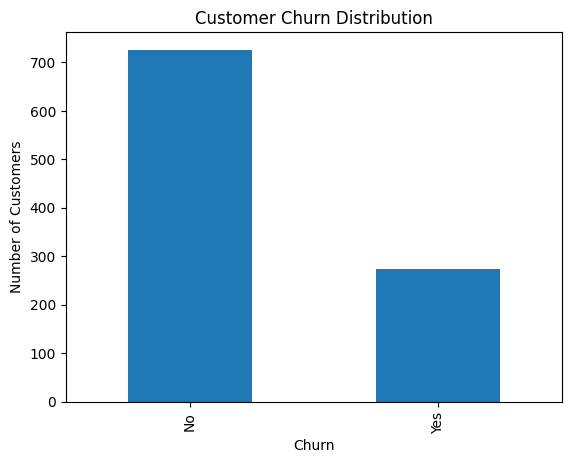

In [20]:
#Python visualization
#Churn distribution
df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

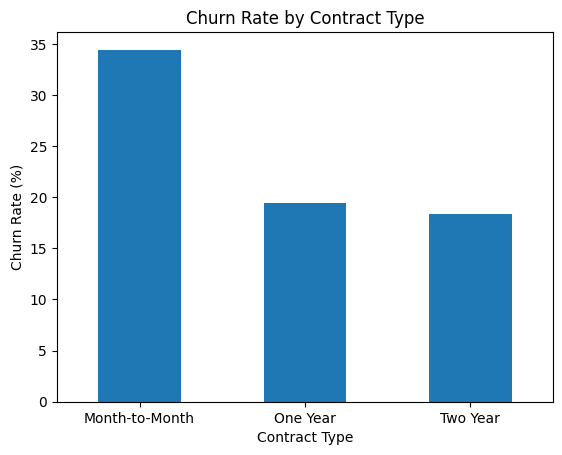

In [21]:
#Contract visualization
contract_churn['Yes'].plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

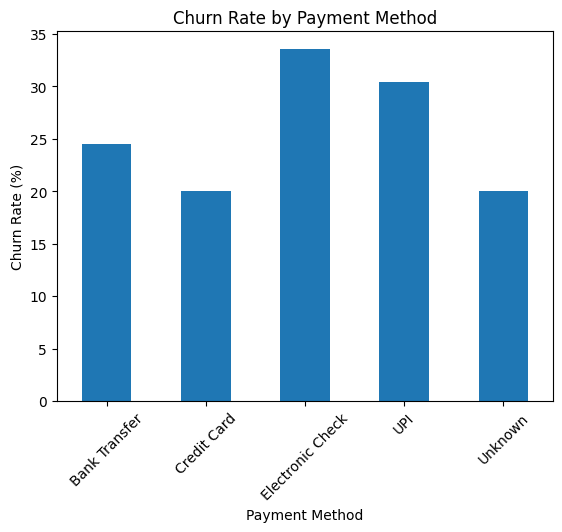

In [22]:
#Payment visualization
payment_churn['Yes'].plot(kind='bar')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

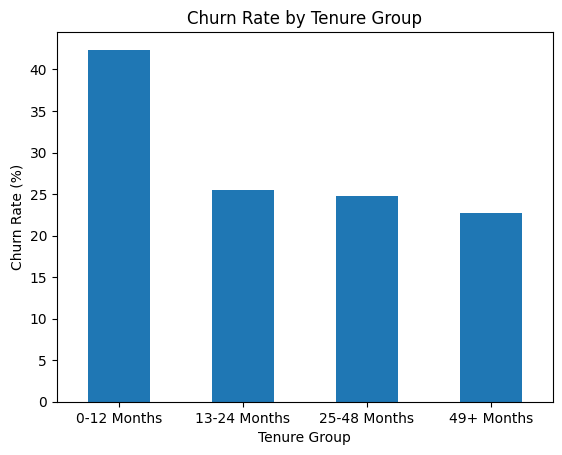

In [23]:
#Tenure visualization
tenure_churn['Yes'].plot(kind='bar')

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()